In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse
import tldextract  
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
import plotly.express as px
import plotly.io as pio
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)
import joblib
from tqdm import tqdm  
import string


In [2]:
data = pd.read_csv("benign_vs_defacement_urls.csv", encoding='ISO-8859-1', on_bad_lines='skip')

C:\Users\HARIKRISHNAN\AppData\Local\Temp\ipykernel_11528\535936760.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("benign_vs_defacement_urls.csv", encoding='ISO-8859-1', on_bad_lines='skip')


In [3]:
data.head()

,url,type,Unnamed: 2
0,mp3raid.com/music/krizz_kaliko.html,benign,NaN
1,bopsecrets.org/rexroth/cr/1.htm,benign,NaN
2,http://buzzfil.net/m/show-art/ils-etaient-loin...,benign,NaN
3,espn.go.com/nba/player/_/id/3457/brandon-rush,benign,NaN
4,yourbittorrent.com/?q=anthony-hamilton-soulife,benign,NaN


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524619 entries, 0 to 524618
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   url         524611 non-null  object
 1   type        524535 non-null  object
 2   Unnamed: 2  3 non-null       object
dtypes: object(3)
memory usage: 12.0+ MB


In [5]:
data.isnull().sum()

url                8
type              84
Unnamed: 2    524616
dtype: int64

In [6]:
data['type'].value_counts()

type
benign                              428078
defacement                           96454
\303\346                                1
\270\300\375&mnid=5080&banner=5         1
%2F                                     1
Name: count, dtype: int64

In [7]:
data = data[['url', 'type']].dropna()
data = data[data['type'].isin(['benign', 'defacement'])]

✅ Test set verification:
Test set size: 171232
Number of unique labels in test set: 2
Label distribution in test set:
 label
1    85846
0    85386
Name: count, dtype: int64
✅ Model saved as 'defacement_detection_model.pkl'

Model Evaluation:
Accuracy : 0.9999299196411886
Precision: 0.9998835231905328
Recall   : 0.9999767024672087
F1 Score : 0.9999301106581246


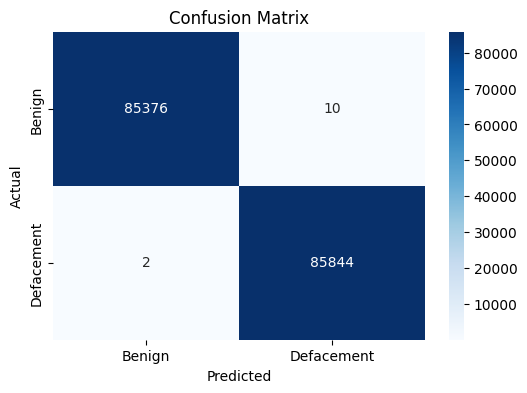

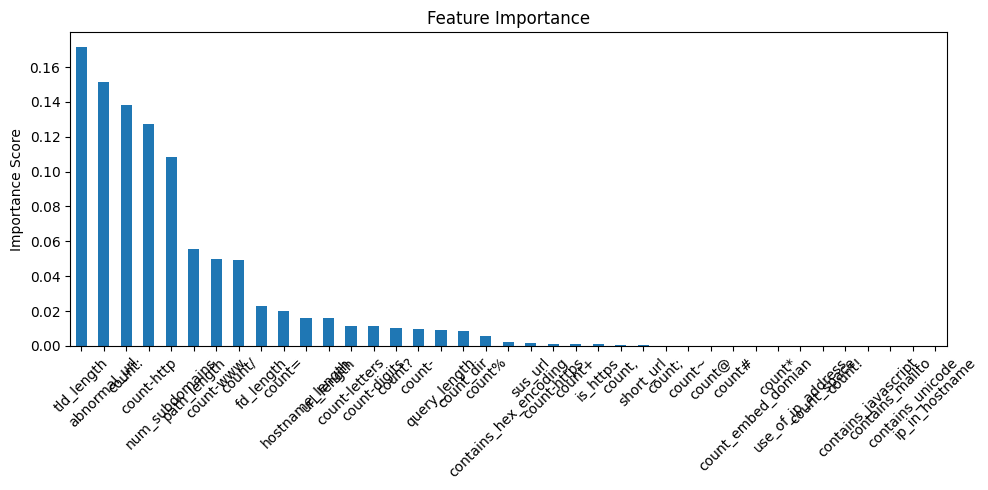

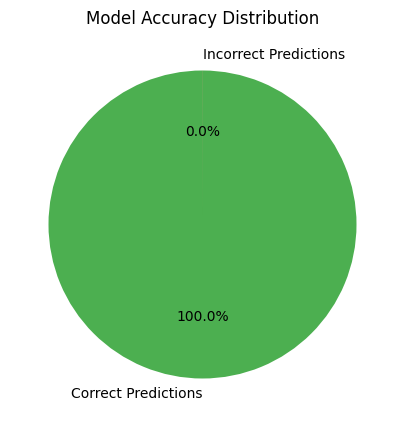

C:\Users\HARIKRISHNAN\AppData\Local\Temp\ipykernel_11528\313612024.py:211: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




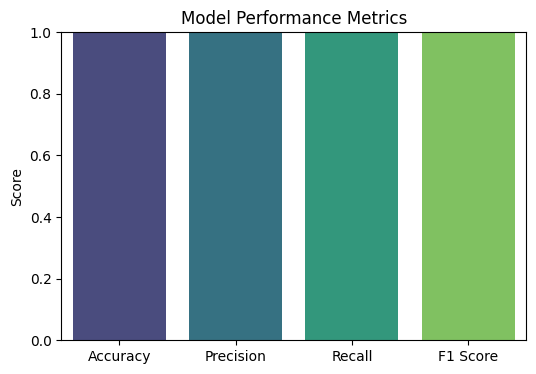

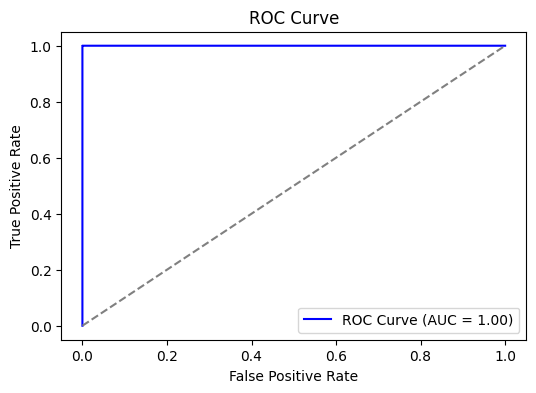

C:\Users\HARIKRISHNAN\AppData\Local\Temp\ipykernel_11528\313612024.py:245: UserWarning:

Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.

C:\Users\HARIKRISHNAN\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.



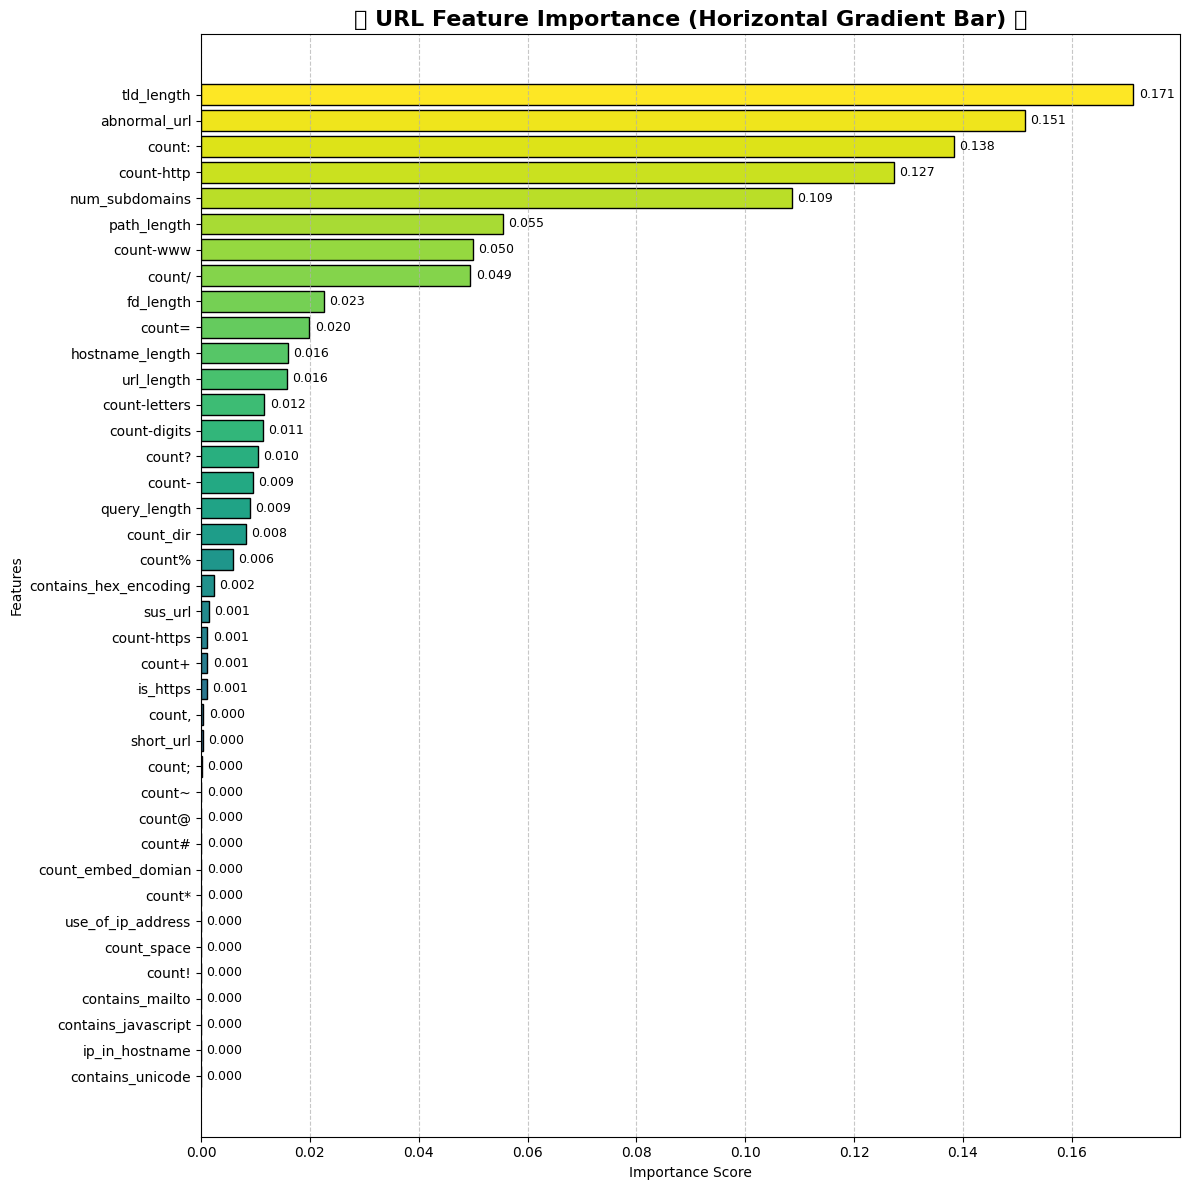

C:\Users\HARIKRISHNAN\AppData\Local\Temp\ipykernel_11528\313612024.py:260: UserWarning:

Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.

C:\Users\HARIKRISHNAN\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.



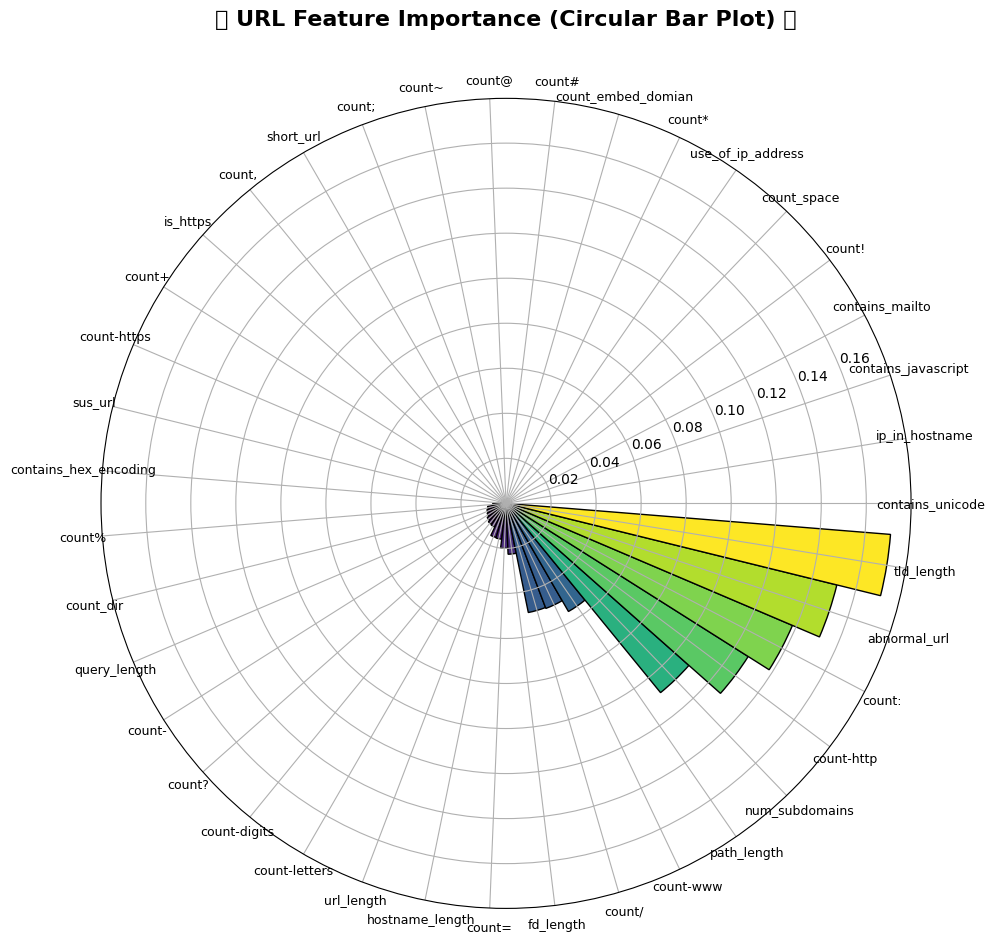

In [ ]:
def url_length(url): return len(str(url)) if pd.notna(url) else 0
def hostname_length(url):
    if pd.isna(url): return 0
    url = str(url).strip()
    if not url.startswith(('http://', 'https://')): url = 'http://' + url
    return len(urlparse(url).netloc)
def safe_count(substring, url):
    return str(url).count(substring) if pd.notna(url) else 0

count_www = lambda url: safe_count('www', url)
count_https = lambda url: safe_count('https', url)
count_http = lambda url: safe_count('http', url)
count_dot = lambda url: safe_count('.', url)
count_per = lambda url: safe_count('%', url)
count_ques = lambda url: safe_count('?', url)
count_hyphen = lambda url: safe_count('-', url)
count_equal = lambda url: safe_count('=', url)
count_atrate = lambda url: safe_count('@', url)
count_slash = lambda url: safe_count('/', url)
count_colon = lambda url: safe_count(':', url)
count_star = lambda url: safe_count('*', url)
count_exclamation = lambda url: safe_count('!', url)
count_comma = lambda url: safe_count(',', url)
count_semicolon = lambda url: safe_count(';', url)
count_space = lambda url: safe_count(' ', url)
count_tilde = lambda url: safe_count('~', url)
count_plus = lambda url: safe_count('+', url)
count_hash = lambda url: safe_count('#', url)
def no_of_dir(url):
    if pd.isna(url): return 0
    return urlparse(str(url)).path.count('/')
def no_of_embed(url):
    if pd.isna(url): return 0
    return urlparse(str(url)).path.count('//')
def shortening_service(url):
    if pd.isna(url): return 0
    pattern = (r'bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|'
               r'yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|'
               r'short\.to|BudURL\.com|ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|'
               r'doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|t\.co|lnkd\.in|'
               r'db\.tt|qr\.ae|adataset\.ly|goo\.gl|bitly\.com|cur\.lv|tinyurl\.com|ow\.ly|bit\.ly|ity\.im|'
               r'q\.gs|is\.gd|po\.st|bc\.vc|twitthis\.com|u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|'
               r'x\.co|prettylinkpro\.com|scrnch\.me|filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|'
               r'tr\.im|link\.zip\.net')
    return 1 if re.search(pattern, str(url)) else 0
def fd_length(url):
    try: return len(urlparse(str(url)).path.split('/')[1])
    except: return 0
def suspicious_words(url):
    return 1 if pd.notna(url) and re.search(r'PayPal|login|signin|bank|account|update|free|lucky|service|bonus|ebayisapi|webscr', str(url), re.I) else 0
def digit_count(url): return sum(1 for c in str(url) if c.isdigit()) if pd.notna(url) else 0
def letter_count(url): return sum(1 for c in str(url) if c.isalpha()) if pd.notna(url) else 0
def abnormal_url(url):
    try:
        host = urlparse(str(url)).hostname
        return 1 if host and re.search(host, str(url)) else 0
    except: return 0
def having_ip_address(url):
    return 1 if pd.notna(url) and re.search(r'(\d{1,3}\.){3}\d{1,3}', str(url)) else 0
def tld_length(url):
    try: return len(urlparse(str(url)).netloc.split('.')[-1])
    except: return 0
def path_length(url): return len(urlparse(str(url)).path) if pd.notna(url) else 0
def query_length(url): return len(urlparse(str(url)).query) if pd.notna(url) else 0
def num_subdomains(url):
    try:
        host = urlparse(str(url)).hostname
        return len(host.split('.')) - 2 if host else 0
    except: return 0
def contains_mailto(url): return 1 if pd.notna(url) and "mailto:" in str(url) else 0
def contains_javascript(url): return 1 if pd.notna(url) and "javascript:" in str(url).lower() else 0
def contains_hex_encoding(url): return 1 if pd.notna(url) and re.search(r'%[0-9a-fA-F]{2}', str(url)) else 0
def contains_unicode(url): return 1 if pd.notna(url) and re.search(r'\\u[0-9a-fA-F]{4}', str(url)) else 0
def is_https(url): return 1 if pd.notna(url) and str(url).lower().startswith('https') else 0
def contains_ip_in_hostname(url):
    try:
        host = urlparse(str(url)).hostname
        return 1 if host and re.match(r'^\d{1,3}(\.\d{1,3}){3}$', host) else 0
    except: return 0

# Extract Features
feature_data = pd.DataFrame()
feature_data['url'] = data['url']
feature_data['label'] = data['type']
feature_data['url_length'] = data['url'].apply(url_length)
feature_data['hostname_length'] = data['url'].apply(hostname_length)
feature_data['count-www'] = data['url'].apply(count_www)
feature_data['count-https'] = data['url'].apply(count_https)
feature_data['count-http'] = data['url'].apply(count_http)
feature_data['count.'] = data['url'].apply(count_dot)
feature_data['count%'] = data['url'].apply(count_per)
feature_data['count?'] = data['url'].apply(count_ques)
feature_data['count-'] = data['url'].apply(count_hyphen)
feature_data['count='] = data['url'].apply(count_equal)
feature_data['count@'] = data['url'].apply(count_atrate)
feature_data['count_dir'] = data['url'].apply(no_of_dir)
feature_data['count_embed_domian'] = data['url'].apply(no_of_embed)
feature_data['short_url'] = data['url'].apply(shortening_service)
feature_data['fd_length'] = data['url'].apply(fd_length)
feature_data['sus_url'] = data['url'].apply(suspicious_words)
feature_data['count-digits'] = data['url'].apply(digit_count)
feature_data['count-letters'] = data['url'].apply(letter_count)
feature_data['abnormal_url'] = data['url'].apply(abnormal_url)
feature_data['use_of_ip_address'] = data['url'].apply(having_ip_address)
feature_data['count/'] = data['url'].apply(count_slash)
feature_data['count:'] = data['url'].apply(count_colon)
feature_data['count*'] = data['url'].apply(count_star)
feature_data['count!'] = data['url'].apply(count_exclamation)
feature_data['count,'] = data['url'].apply(count_comma)
feature_data['count;'] = data['url'].apply(count_semicolon)
feature_data['count_space'] = data['url'].apply(count_space)
feature_data['count~'] = data['url'].apply(count_tilde)
feature_data['count+'] = data['url'].apply(count_plus)
feature_data['count#'] = data['url'].apply(count_hash)
feature_data['tld_length'] = data['url'].apply(tld_length)
feature_data['path_length'] = data['url'].apply(path_length)
feature_data['query_length'] = data['url'].apply(query_length)
feature_data['num_subdomains'] = data['url'].apply(num_subdomains)
feature_data['contains_mailto'] = data['url'].apply(contains_mailto)
feature_data['contains_javascript'] = data['url'].apply(contains_javascript)
feature_data['contains_hex_encoding'] = data['url'].apply(contains_hex_encoding)
feature_data['contains_unicode'] = data['url'].apply(contains_unicode)
feature_data['is_https'] = data['url'].apply(is_https)
feature_data['ip_in_hostname'] = data['url'].apply(contains_ip_in_hostname)

# Save extracted features to CSV 
feature_data.to_csv("extracted_url_features.csv", index=False)

# Balancing the Dataset 
max_samples = feature_data['label'].value_counts().max()
bad_data = feature_data[feature_data['label'] == 'defacement']
good_data = feature_data[feature_data['label'] == 'benign']
oversampled_bad = resample(bad_data, replace=True, n_samples=max_samples, random_state=42)
undersampled_good = good_data.sample(n=max_samples, random_state=42)
balanced_data = pd.concat([oversampled_bad, undersampled_good]).sample(frac=1)

# Model Training 
le = LabelEncoder()
balanced_data['label'] = le.fit_transform(balanced_data['label'])  # 0: benign, 1: defacement

features = [
    'use_of_ip_address', 'abnormal_url', 'count-www', 'count@', 'count_dir',
    'count_embed_domian', 'short_url', 'count-https', 'count-http', 'count%',
    'count?', 'count-', 'count=', 'url_length', 'hostname_length', 'sus_url',
    'fd_length', 'count-digits', 'count-letters',
    'count/', 'count:', 'count*', 'count!', 'count,', 'count;', 'count_space',
    'count~', 'count+', 'count#', 'tld_length', 'path_length', 'query_length',
    'num_subdomains', 'contains_mailto', 'contains_javascript',
    'contains_hex_encoding', 'contains_unicode', 'is_https', 'ip_in_hostname'
]

X = balanced_data[features]
y = balanced_data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Verify Test Set
print("✅ Test set verification:")
print("Test set size:", len(y_test))
print("Number of unique labels in test set:", y_test.nunique())
print("Label distribution in test set:\n", y_test.value_counts())

# Saving the Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
joblib.dump(model, 'defacement_detection_model.pkl')
print("✅ Model saved as 'defacement_detection_model.pkl'")

# Evaluation
y_pred = model.predict(X_test)
print("\nModel Evaluation:")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Defacement'], yticklabels=['Benign', 'Defacement'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature importance
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
importances.plot(kind='bar')
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 1) Pie Chart: Accuracy vs Error 
accuracy = accuracy_score(y_test, y_pred)
error = 1 - accuracy
plt.figure(figsize=(5,5))
plt.pie([accuracy, error], labels=["Correct Predictions", "Incorrect Predictions"], 
        autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90)
plt.title("Model Accuracy Distribution")
plt.show()

# 2) Bar Chart: Accuracy, Precision, Recall, F1 
metrics_scores = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred)
}
plt.figure(figsize=(6,4))
sns.barplot(x=list(metrics_scores.keys()), y=list(metrics_scores.values()), palette="viridis")
plt.ylim(0, 1)
plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.show()

# 3) ROC Curve 
y_pred_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='blue', label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Prepare Feature Importance 
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

# 4) Horizontal Gradient Bar Plot 
plt.figure(figsize=(12, 12))
colors = plt.cm.viridis(np.linspace(0, 1, len(importances)))  # Gradient colors
bars = plt.barh(importances.index, importances.values, color=colors, edgecolor='black')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center', fontsize=9)
plt.title("🔥 URL Feature Importance (Horizontal Gradient Bar) 🔥", fontsize=16, fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 5) Circular / Radial Bar Plot 
theta = np.linspace(0.0, 2 * np.pi, len(importances), endpoint=False)
radii = importances.values
width = 2 * np.pi / len(importances)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, polar=True)
bars = ax.bar(theta, radii, width=width, bottom=0.0, color=plt.cm.viridis(radii/radii.max()), edgecolor='black')

ax.set_xticks(theta)
ax.set_xticklabels(importances.index, fontsize=9)
ax.set_title("🔵 URL Feature Importance (Circular Bar Plot) 🔵", fontsize=16, fontweight='bold', y=1.08)
plt.tight_layout()
plt.show()

importances_sorted = importances.sort_values(ascending=False)

# 6) Treemap of Feature Importance 
pio.renderers.default = "browser"
fig_tree = px.treemap(
    names=importances_sorted.index,
    parents=[""]*len(importances_sorted),
    values=importances_sorted.values,
    color=importances_sorted.values,
    color_continuous_scale='Viridis',
    title="🌳 Feature Importance Treemap"
)
fig_tree.show()


# Predict New URL 
def predict_url(url):
    row = pd.DataFrame([{
        'url_length': url_length(url),
        'hostname_length': hostname_length(url),
        'count-www': count_www(url),
        'count-https': count_https(url),
        'count-http': count_http(url),
        'count.': count_dot(url),
        'count%': count_per(url),
        'count?': count_ques(url),
        'count-': count_hyphen(url),
        'count=': count_equal(url),
        'count@': count_atrate(url),
        'count_dir': no_of_dir(url),
        'count_embed_domian': no_of_embed(url),
        'short_url': shortening_service(url),
        'fd_length': fd_length(url),
        'sus_url': suspicious_words(url),
        'count-digits': digit_count(url),
        'count-letters': letter_count(url),
        'abnormal_url': abnormal_url(url),
        'use_of_ip_address': having_ip_address(url),
        'count/': count_slash(url),
        'count:': count_colon(url),
        'count*': count_star(url),
        'count!': count_exclamation(url),
        'count,': count_comma(url),
        'count;': count_semicolon(url),
        'count_space': count_space(url),
        'count~': count_tilde(url),
        'count+': count_plus(url),
        'count#': count_hash(url),
        'tld_length': tld_length(url),
        'path_length': path_length(url),
        'query_length': query_length(url),
        'num_subdomains': num_subdomains(url),
        'contains_mailto': contains_mailto(url),
        'contains_javascript': contains_javascript(url),
        'contains_hex_encoding': contains_hex_encoding(url),
        'contains_unicode': contains_unicode(url),
        'is_https': is_https(url),
        'ip_in_hostname': contains_ip_in_hostname(url)

    }])

    row = row[features]
    prediction = model.predict(row)[0]
    return "🔴 Malicious (Defacement)" if prediction == 1 else "🟢 Benign"

# Predict loop
while True:
    url = input("\nEnter a URL to check (or type 'q' to quit): ")
    if url.lower() == 'q':
        break
    print("Prediction:", predict_url(url), flush=True)
